In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.xpu import device

BATCH_SIZE = 128
EPOCHS = 10
LR = 0.001
VAL_SIZE = 10000
RANDOM_SEED = 42

In [2]:
#Reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Handwritten Digit Classification — MNIST

In this project I explore the problem of handwritten digit recognition using the **MNIST dataset**, a widely used benchmark for image classification in machine learning. The goal is to build and evaluate neural network models capable of correctly identifying digits (0–9) from grayscale images.

The project begins with a simple **baseline model based on a Multilayer Perceptron (MLP)** in order to establish a reference performance for the task. Next, a **Convolutional Neural Network (CNN)** is implemented to take advantage of spatial information present in images.

After establishing the CNN baseline, a series of experiments is performed to analyze how different architectural and training choices influence model performance. These experiments include modifying the **network width and depth**, as well as applying common regularization techniques such as **Batch Normalization** and **Dropout**.

The objective of this project is not only to train an accurate model, but also to understand how various design decisions affect training dynamics, generalization ability, and classification performance. Model behavior is analyzed using training and validation curves, as well as confusion matrices that help identify which digits are most frequently misclassified.

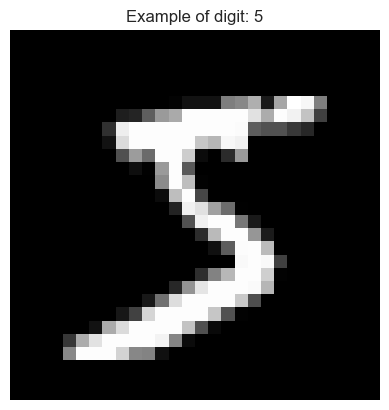

In [3]:
# loading the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Example of digit: {y_train[0]}")
plt.axis('off')
plt.show()

In [4]:
print(f"x_train: {X_train.shape}\nx_test: {X_test.shape}")
print(f"Type of data: {type(X_train[0])}")
ds_len = len(X_test) + len(X_train)

# counting the ratio of sets
def ds_percent(part):
    return np.round(len(part)/ds_len*100, 1)

print(f"Train/Test: {ds_percent(X_train)}/{ds_percent(X_test)}")

x_train: (60000, 28, 28)
x_test: (10000, 28, 28)
Type of data: <class 'numpy.ndarray'>
Train/Test: 85.7/14.3


# Normalizing and Standardizing the Data
Every pixel has a value between <0-255>. To normalize the data, I divided each value by 255.
In MNIST dataset mean is 0.1037 and standard deviation is 0.3081. To standardize the data, i will use the formula $z=\frac{x - \mu}{\sigma}$

In [5]:
X_train, X_test = (X_train/255.0).astype('float32'), (X_test/255.0).astype('float32')
mean = X_train.mean()
std = X_train.std()
X_train, X_test = (X_train - mean) / std, (X_test - mean) / std
print(X_train.mean())

2.2421078e-08


# Creating a Dataset
First, we need to create a dataset class, so data is readable for torch, and make a training and testing set.

In [6]:
class MNISTDataset(Dataset):
    def __init__(self, data, labels):
        if len(data) != len(labels):
            raise ValueError("Dataset must have the same length as labels")
        self.data = data
        self.labels = labels
        if not isinstance(self.data, torch.Tensor):
            self.data = torch.from_numpy(self.data)
        if not isinstance(self.labels, torch.Tensor):
            self.labels = torch.from_numpy(self.labels)
        self.data = self.data.unsqueeze(1) # added a dimension of the channel (greyscale = 1) for conv2d layer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        label = self.labels[idx]
        return sample, label

train_full = MNISTDataset(X_train, y_train)
test_set = MNISTDataset(X_test, y_test)

# Extracting a Validation Set from Training Set
I decided on the ratio train/test/val 70/15/15.

In [7]:
train_size = len(train_full) - VAL_SIZE
assert train_size + VAL_SIZE == len(train_full)
train_set, val_set = random_split(train_full, [train_size, VAL_SIZE], generator=torch.Generator().manual_seed(RANDOM_SEED))
print(f"Train/Test/Val: {ds_percent(train_set)}/{ds_percent(test_set)}/{ds_percent(val_set)} {len(train_set)}/{len(test_set)}/{len(val_set)}")

Train/Test/Val: 71.4/14.3/14.3 50000/10000/10000


# Creating DataLoaders

In [8]:
train_loader  = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# Data Visualisation

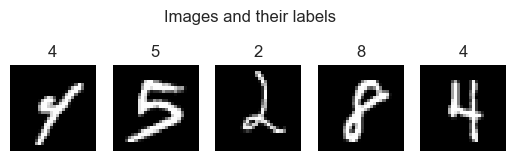

In [9]:
def show_img_label(imgs, labels, are_predicted):
    fig, ax = plt.subplots(1,len(imgs))
    for i in range(len(imgs)):
        ax[i].imshow(imgs[i], cmap='gray')
        ax[i].set_title(labels[i].item())
        ax[i].set_axis_off()
    if are_predicted:
        fig.suptitle('Images and the predicted values')
    else:
        fig.suptitle("Images and their labels", y=0.7)
    plt.show()

data_batch, labels_batch = next(iter(val_loader))
data_batch = data_batch[:5]
labels_batch = labels_batch[:5]
show_img_label(data_batch.squeeze(), labels_batch, False)


In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Baseline Model
As a baseline, I used a simple fully connected neural network consisting of two linear layers with a ReLU activation function.
The input images are flattened and passed through the network to predict one of the ten digit classes.

The model is trained on the training set for 10 epochs using the Adam optimizer and cross-entropy loss.
A validation set is used to monitor the training process and evaluate the model's performance during training.

In [11]:
class BaselineNN(nn.Module):
    def __init__(self, input_size=784, hidden_size=128, output_size=10):
        super().__init__()
        self.layer1 = nn.Flatten()
        self.layer2 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        return x

baseline_model = BaselineNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(baseline_model.parameters(), lr=LR)

def run_train_epoch(loader, model, optimizer, criterion):
    model.train()
    epoch_loss, correct, total = 0,0,0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x_batch.size(0)
        preds = predictions.argmax(1)
        correct += (preds==y_batch).sum().item()
        total += y_batch.size(0)
    return epoch_loss / total, correct / total

def run_val_epoch(loader, model, criterion):
    epoch_loss, correct, total = 0,0,0
    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            predictions = model(x_batch)
            loss = criterion(predictions, y_batch)

            epoch_loss += loss.item() * x_batch.size(0)
            preds = predictions.argmax(1)
            correct += (preds==y_batch).sum().item()
            total += y_batch.size(0)
    return epoch_loss / total, correct / total



In [12]:
def run_epochs(epochs, train_loader, val_loader, model, optimizer, criterion):
    history = {
        "train_loss_arr": [], "train_acc_arr": [],
        "val_loss_arr":   [], "val_acc_arr":   []
    }
    for epoch in range(epochs):
        train_loss, train_accuracy = run_train_epoch(train_loader, model, optimizer, criterion)
        val_loss, val_accuracy = run_val_epoch(val_loader, model, criterion)

        history["train_loss_arr"].append(train_loss)
        history["train_acc_arr"].append(train_accuracy)

        history["val_loss_arr"].append(val_loss)
        history["val_acc_arr"].append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs} | train loss: {train_loss:.4f}, acc: {train_accuracy:.4f} | val loss: {val_loss:.4f}, acc: {val_accuracy:.4f}")

    return history

history = run_epochs(EPOCHS, train_loader, val_loader, baseline_model, optimizer, criterion)


Epoch 1/10 | train loss: 0.3238, acc: 0.9056 | val loss: 0.1862, acc: 0.9454
Epoch 2/10 | train loss: 0.1429, acc: 0.9586 | val loss: 0.1400, acc: 0.9586
Epoch 3/10 | train loss: 0.0992, acc: 0.9709 | val loss: 0.1214, acc: 0.9622
Epoch 4/10 | train loss: 0.0767, acc: 0.9772 | val loss: 0.1012, acc: 0.9689
Epoch 5/10 | train loss: 0.0605, acc: 0.9818 | val loss: 0.1044, acc: 0.9684
Epoch 6/10 | train loss: 0.0491, acc: 0.9853 | val loss: 0.0977, acc: 0.9698
Epoch 7/10 | train loss: 0.0396, acc: 0.9883 | val loss: 0.0912, acc: 0.9714
Epoch 8/10 | train loss: 0.0319, acc: 0.9908 | val loss: 0.0949, acc: 0.9730
Epoch 9/10 | train loss: 0.0271, acc: 0.9918 | val loss: 0.0911, acc: 0.9742
Epoch 10/10 | train loss: 0.0231, acc: 0.9931 | val loss: 0.0956, acc: 0.9727


# Monitoring the training process

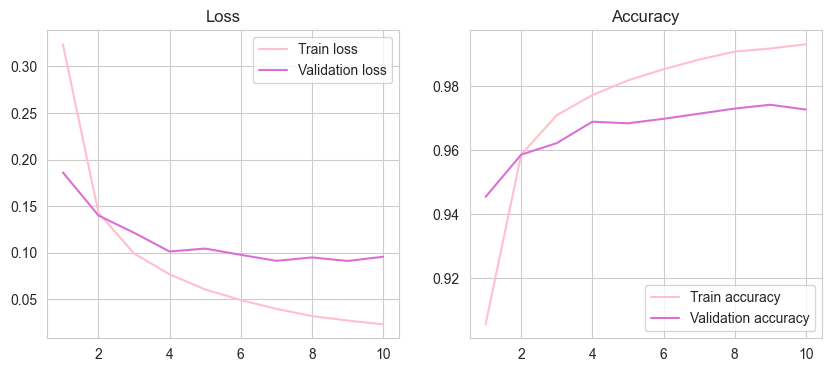

In [13]:
def show_training_process(train_los, val_los, train_acc, val_acc):
    x = []
    for i in range(len(train_los)):
        x.append(i+1)
    x = np.array(x)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(x, train_los, label='Train loss', color='pink')
    plt.plot(x, val_los, label='Validation loss', color='orchid')
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(x, train_acc, label='Train accuracy', color='pink')
    plt.plot(x, val_acc, label='Validation accuracy', color='orchid')
    plt.title("Accuracy")
    plt.legend()
    plt.show()

show_training_process(history["train_loss_arr"], history["val_loss_arr"], history["train_acc_arr"], history["val_acc_arr"])

# Final Results for Baseline Model
This result serves as a reference point for evaluating more advanced architectures such as convolutional neural networks.

In [14]:
loss, accuracy = run_val_epoch(test_loader, baseline_model, criterion)
print("Baseline Test Performance: ")
print(f"Accuracy: {np.round(accuracy, 2)}")
print(f"Loss: {np.round(loss,2)}")

Baseline Test Performance: 
Accuracy: 0.98
Loss: 0.07


# CNN Model

In [15]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.conv1(x)) # 8 features
        x = self.pool(self.relu(self.conv2(x))) # 16 features img 14x14
        x = self.pool(self.relu(self.conv3(x))) # 24 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_model = CNNModel().to(device)

# Training of CNN Model
After 7 epochs, the training accuracy keeps increasing (up to 0.9966), while the validation accuracy plateaus around ~0.989.
The best validation accuracy (0.9895) is achieved at epoch 7. After that point, validation performance fluctuates slightly and does not improve. It suggests diminishing returns from additional training and the beginning of overfitting. Therefore, epoch 7 can be treated as the optimal checkpoint for this baseline model.

Epoch 1/10 | train loss: 0.3316, acc: 0.9008 | val loss: 0.0972, acc: 0.9711
Epoch 2/10 | train loss: 0.0751, acc: 0.9768 | val loss: 0.0647, acc: 0.9816
Epoch 3/10 | train loss: 0.0502, acc: 0.9842 | val loss: 0.0518, acc: 0.9847
Epoch 4/10 | train loss: 0.0370, acc: 0.9884 | val loss: 0.0490, acc: 0.9844
Epoch 5/10 | train loss: 0.0301, acc: 0.9908 | val loss: 0.0384, acc: 0.9892
Epoch 6/10 | train loss: 0.0232, acc: 0.9930 | val loss: 0.0426, acc: 0.9878
Epoch 7/10 | train loss: 0.0207, acc: 0.9938 | val loss: 0.0426, acc: 0.9876
Epoch 8/10 | train loss: 0.0166, acc: 0.9947 | val loss: 0.0424, acc: 0.9867
Epoch 9/10 | train loss: 0.0150, acc: 0.9953 | val loss: 0.0399, acc: 0.9889
Epoch 10/10 | train loss: 0.0116, acc: 0.9964 | val loss: 0.0432, acc: 0.9874


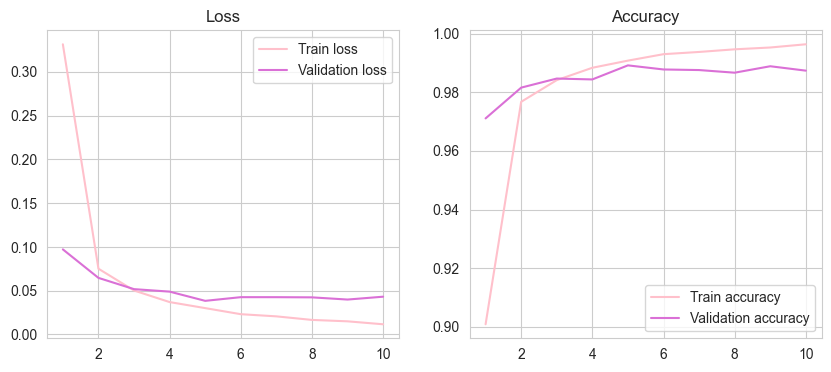

In [16]:
optimizer = Adam(cnn_model.parameters(), lr=LR)

history = run_epochs(EPOCHS, train_loader, val_loader, cnn_model, optimizer, criterion)
show_training_process(history["train_loss_arr"], history["val_loss_arr"], history["train_acc_arr"], history["val_acc_arr"])

In addition to accuracy, a confusion matrix is presented to analyze which digits are most frequently misclassified.


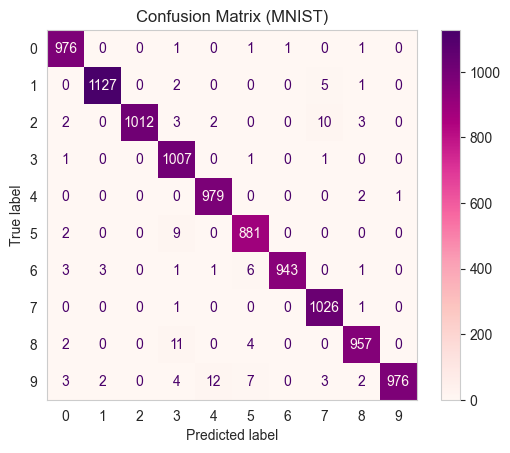

Test accuracy: 0.9884


In [17]:
def run_test(model, loader):
    model.eval()
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            preds = model(x_batch)
            preds = preds.argmax(1).cpu().numpy()
            all_predictions.append(preds)
            all_targets.append(y_batch.numpy())

    all_predictions = np.concatenate(all_predictions)
    all_targets = np.concatenate(all_targets)
    labels = list(range(10))
    cm = confusion_matrix(all_targets, all_predictions)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
    cm_display.plot(cmap='RdPu')
    plt.title("Confusion Matrix (MNIST)")
    plt.gca().grid(False)
    plt.show()

    acc = (all_predictions == all_targets).mean()
    print(f"Test accuracy: {np.round(acc,4)}")

run_test(cnn_model, test_loader)

# Hyperparameter Tuning
I chose accuracy as the main evaluation metric because MNIST is a balanced multi-class classification problem. Therefore, accuracy directly reflects the proportion of correctly classified images and is easy to interpret. My plan of experiments with hyperparameter tuning is as follows:
- network width (more channels)
- network depth (more convolutional layers)
- Batch Normalization
- Dropout


## 1. More Channels
Increasing the number of convolutional channels did not significantly change the model performance.
The training accuracy reached values similar to the baseline model, while the validation accuracy remained around 0.988–0.989 and did not exceed 0.99. This indicates that increasing the network width did not provide a noticeable improvement for this task.

In [18]:
class CNN_wider(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(16,32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(32,64, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3136, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.conv1(x)) # 16 features
        x = self.pool(self.relu(self.conv2(x))) # 32 features img 14x14
        x = self.pool(self.relu(self.conv3(x))) # 64 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_wider = CNN_wider().to(device)

In [ ]:
EPOCHS = 7
optimizer = Adam(cnn_wider.parameters(), lr=LR)
history = run_epochs(7, train_loader, val_loader, cnn_wider, optimizer, criterion)

Epoch 1/7 | train loss: 0.2026, acc: 0.9392 | val loss: 0.0710, acc: 0.9778
Epoch 2/7 | train loss: 0.0523, acc: 0.9839 | val loss: 0.0479, acc: 0.9857


## 2. More Convolutional Layers
Increasing network depth (adding an additional convolutional layer) did not improve validation performance.
Validation accuracy remained in a similar range and did not surpass the baseline CNN results.
This suggests that the baseline architecture is already sufficient for MNIST and the extra depth mainly increases model capacity without improving generalization.

In [19]:
class CNN_deeper(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(24,24, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)

    def forward(self,x):
        x = self.relu(self.conv1(x)) # 8 features
        x = self.pool(self.relu(self.conv2(x))) # 16 features img 14x14
        x = self.relu(self.conv3(x)) # 24 features img 14x14
        x = self.pool(self.relu(self.conv4(x))) # 24 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_deeper = CNN_deeper().to(device)

In [20]:
optimizer = Adam(cnn_deeper.parameters(), lr=LR)
history = run_epochs(EPOCHS, train_loader, val_loader, cnn_deeper, optimizer, criterion)

Epoch: 1
Training: Loss: 0.31789963553905487	Accuracy: 0.90322
Validation: Loss: 0.0911577648639679	Accuracy: 0.9718
Epoch: 2
Training: Loss: 0.07033335671424866	Accuracy: 0.97876
Validation: Loss: 0.07722746748924256	Accuracy: 0.9747
Epoch: 3
Training: Loss: 0.046885070130825046	Accuracy: 0.98528
Validation: Loss: 0.05672643755674362	Accuracy: 0.983
Epoch: 4
Training: Loss: 0.03585609445869923	Accuracy: 0.98878
Validation: Loss: 0.044184562453627584	Accuracy: 0.9872
Epoch: 5
Training: Loss: 0.027710487770438195	Accuracy: 0.99128
Validation: Loss: 0.05231457325518131	Accuracy: 0.9846
Epoch: 6
Training: Loss: 0.022132693106979132	Accuracy: 0.9928
Validation: Loss: 0.04879367570579052	Accuracy: 0.9855
Epoch: 7
Training: Loss: 0.01939046862669289	Accuracy: 0.99372
Validation: Loss: 0.04144189330823719	Accuracy: 0.9874


## 3. Batch Normalization
Adding Batch Normalization did not lead to a significant improvement in validation performance. The validation accuracy slightly increased but remained below the 0.99 threshold, reaching a maximum of 0.9894. Therefore, the overall performance is comparable to the baseline CNN.

In [21]:
class CNN_batch(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(24)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.bn1(self.conv1(x))) # 8 features
        x = self.pool(self.relu(self.bn2(self.conv2(x)))) # 16 features img 14x14
        x = self.pool(self.relu(self.bn3(self.conv3(x)))) # 24 features img 7x7
        x = self.relu(self.fc1(self.flatten(x)))
        x = self.output(x)
        return x

cnn_batch = CNN_batch().to(device)

In [22]:
optimizer = Adam(cnn_batch.parameters(), lr=LR)
history = run_epochs(EPOCHS, train_loader, val_loader, cnn_batch, optimizer, criterion)

Epoch: 1
Training: Loss: 0.1645109315085411	Accuracy: 0.95344
Validation: Loss: 0.06848870838880539	Accuracy: 0.9792
Epoch: 2
Training: Loss: 0.05044833166241646	Accuracy: 0.9844
Validation: Loss: 0.054376296854019165	Accuracy: 0.984
Epoch: 3
Training: Loss: 0.03580804714664817	Accuracy: 0.9887
Validation: Loss: 0.060412165439128876	Accuracy: 0.9806
Epoch: 4
Training: Loss: 0.02800678754091263	Accuracy: 0.99138
Validation: Loss: 0.06492872338294983	Accuracy: 0.9809
Epoch: 5
Training: Loss: 0.023630628999620675	Accuracy: 0.9922
Validation: Loss: 0.045921643143892285	Accuracy: 0.9856
Epoch: 6
Training: Loss: 0.018044712824225425	Accuracy: 0.99416
Validation: Loss: 0.04437668859064579	Accuracy: 0.9872
Epoch: 7
Training: Loss: 0.013849130979925394	Accuracy: 0.99578
Validation: Loss: 0.034840205465257165	Accuracy: 0.9889


## 4. Dropout
The best results were obtained with the model using Dropout and a larger batch size. The validation accuracy exceeded the 0.99 threshold, reaching 0.9909 at epoch 7. Compared to previous experiments (baseline, wider network, deeper network and BatchNorm), this configuration achieved the highest validation performance while maintaining a small gap between training and validation accuracy. As this is the best-performing model, it will be evaluated on the test dataset and a confusion matrix will be generated to compare its performance with the baseline CNN model.

In [23]:
class CNN_dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,8,kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.conv2 = nn.Conv2d(8,16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv3 = nn.Conv2d(16,24, kernel_size=3, padding=1)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(1176, 100)
        self.output = nn.Linear(100, 10)


    def forward(self,x):
        x = self.relu(self.conv1(x)) # 8 features
        x = self.pool(self.relu(self.conv2(x)))# 16 features img 14x14
        x = self.pool(self.relu(self.conv3(x))) # 24 features img 7x7

        x = self.flatten(x)
        x = self.dropout(x)

        x = self.relu(self.fc1(x))
        x = self.output(x)
        return x

cnn_dropout = CNN_dropout().to(device)

In [24]:
EPOCHS = 10
optimizer = Adam(cnn_dropout.parameters(), lr = LR)
history = run_epochs(EPOCHS, train_loader, val_loader, cnn_dropout, optimizer, criterion)

Epoch: 1
Training: Loss: 0.32122050780773165	Accuracy: 0.90094
Validation: Loss: 0.09723804636001587	Accuracy: 0.9715
Epoch: 2
Training: Loss: 0.08787511482954025	Accuracy: 0.97218
Validation: Loss: 0.06342960096597672	Accuracy: 0.9807
Epoch: 3
Training: Loss: 0.06415773239314557	Accuracy: 0.98006
Validation: Loss: 0.05374640152454376	Accuracy: 0.9835
Epoch: 4
Training: Loss: 0.05160169580698013	Accuracy: 0.98378
Validation: Loss: 0.043067538648843766	Accuracy: 0.9862
Epoch: 5
Training: Loss: 0.04411366015225649	Accuracy: 0.98554
Validation: Loss: 0.042034900593757626	Accuracy: 0.9883
Epoch: 6
Training: Loss: 0.03892747300267219	Accuracy: 0.98754
Validation: Loss: 0.03833763322234154	Accuracy: 0.9879
Epoch: 7
Training: Loss: 0.03529687511026859	Accuracy: 0.98844
Validation: Loss: 0.04338505459725857	Accuracy: 0.9864
Epoch: 8
Training: Loss: 0.03107509530901909	Accuracy: 0.98966
Validation: Loss: 0.03816538651883602	Accuracy: 0.9884
Epoch: 9
Training: Loss: 0.02891023372218013	Accuracy:

Confusion matrix of dropout layer shows much higher accuracy: 0.9917. This is the highest obtained value, proving that with MNIST using dropout layer with p=0.3 is a good choice.

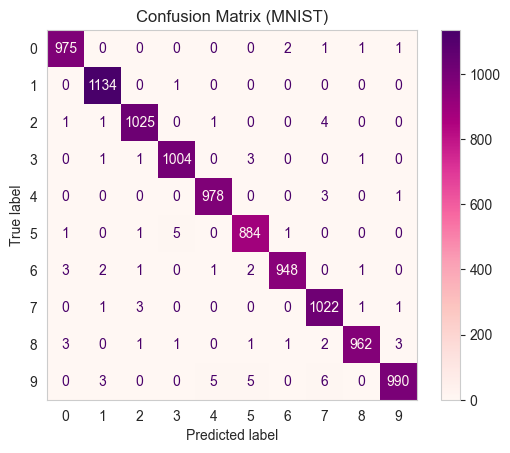

Test accuracy: 0.9922


In [28]:
run_test(cnn_dropout, test_loader)

# Summary

In this project I implemented and compared several neural network architectures for digit classification on the MNIST dataset.

As a starting point, I trained a simple **Multilayer Perceptron (MLP)** model to establish a basic performance baseline. Since this model does not use spatial information from the images, it serves as a reference for how well a fully connected network performs on this task.

Next, I implemented a **baseline convolutional neural network (CNN)**, which achieved a test accuracy of **0.9879**. This model served as the main reference point for further CNN architecture experiments.

Several architectural modifications were then explored:
- increasing the number of convolutional channels
- increasing the network depth
- adding Batch Normalization
- adding Dropout

The experiments showed that increasing the network width and depth did not significantly improve performance — validation accuracy remained around **0.988–0.989**. Adding Batch Normalization stabilized training but also did not lead to a noticeable accuracy gain.

The best results were obtained when introducing **Dropout (p = 0.3)** together with a larger batch size. This configuration achieved a test accuracy of **0.9917**, outperforming the baseline CNN.

To better understand model performance, confusion matrices were generated for both the baseline CNN and the final CNN with Dropout, allowing a comparison of the most common misclassifications.